In [ ]:
import pandas as pd
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/ai_job_market.csv'
data = pd.read_csv(path)
data.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [ ]:
print(data.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['job_id', 'company_name', 'industry', 'job_title', 'skills_required',
       'experience_level', 'employment_type', 'location', 'salary_range_usd',
       'posted_date', 'company_size', 'tools_preferred'],
      dtype='object')>


In [ ]:
data.shape

(2000, 12)

In [ ]:
data['description'] = (
    data['job_title'].astype(str)
    + " " +
    data['skills_required'].astype(str)
    + " " +
    data['tools_preferred'].astype(str)
    + " " +
    data['industry'].astype(str)
    + " " +
    data['location'].astype(str)
    + " " +
    data['experience_level'].astype(str)
)

In [ ]:
data = data.dropna(subset=['description'])

In [ ]:
print(f"Shape of DataFrame before dropping duplicates: {data.shape}")
data.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after dropping duplicates: {data.shape}")

Shape of DataFrame before dropping duplicates: (2000, 13)
Shape of DataFrame after dropping duplicates: (2000, 13)


In [ ]:
!pip install pymupdf sentence-transformers

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Resume 1.pdf to Resume 1 (2).pdf


In [ ]:
import fitz
uploaded = files.upload()

pdf_file = list(uploaded.keys())[0]

doc = fitz.open(pdf_file)

resume_text = ""

for page in doc:
    resume_text += page.get_text()

print(resume_text[:3000])

Saving Resume 1.pdf to Resume 1 (3).pdf
Powered by ResumeGemini
SHITIZ KUMAR
Summary
AI & Machine Learning professional with hands-on experience in predictive modeling, data analysis, and end-to-end ML
solutions. Completed the AI Engineer Program from Simplilearn, with strong proficiency in Python, Pandas, NumPy, and
Scikit-learn.
Experienced in delivering data-driven projects across retail analytics, loan prediction, cohort analysis, and employee attrition,
with a focus on generating actionable insights and solving real-world business problems.
Skills
Python
data visualisati
NLP
problem solving
Feature Engineering
Deep learning
Model Evaluation
Statistical modeling
Effective communication
Neural networks
Data wrangling
Sentiment analysis
Data cleaning
Multitasking capacity
Education
Sri Dev Suman Uttarakhand University, Tehri
Bachelor of Science (B.Sc.)
2025
Simplilearn
certification course - Ai Engineer
Apr 2026
Accomplishments
Completed AI Engineering Certification with hands-on pro

In [ ]:
import re

cleaned_text = resume_text.lower()

cleaned_text = re.sub(r'[^a-zA-Z0-9 ]', ' ', cleaned_text)

print(cleaned_text[:2000])

powered by resumegemini shitiz kumar summary ai   machine learning professional with hands on experience in predictive modeling  data analysis  and end to end ml solutions  completed the ai engineer program from simplilearn  with strong proficiency in python  pandas  numpy  and scikit learn  experienced in delivering data driven projects across retail analytics  loan prediction  cohort analysis  and employee attrition  with a focus on generating actionable insights and solving real world business problems  skills python data visualisati nlp problem solving feature engineering deep learning model evaluation statistical modeling effective communication neural networks data wrangling sentiment analysis data cleaning multitasking capacity education sri dev suman uttarakhand university  tehri bachelor of science  b sc   2025 simplilearn certification course   ai engineer apr 2026 accomplishments completed ai engineering certification with hands on projects in machine learning and data analy

### Initialize Candidate Profile and Job Titles

In [ ]:
# Initialize candidate_profile dictionary
candidate_profile = {}

# Define common job titles for extraction heuristic
common_job_titles = [
    "data scientist", "machine learning engineer", "ai engineer",
    "data analyst", "software engineer", "backend developer",
    "frontend developer", "full stack developer", "devops engineer",
    "cloud engineer", "research scientist", "quant researcher",
    "computer vision engineer", "nlp engineer"
]

In [ ]:
import pandas as pd
import re

# Extract all skills from 'skills_required' and 'tools_preferred' columns
all_skills = data['skills_required'].str.split(', ').explode().tolist()
all_tools = data['tools_preferred'].str.split(', ').explode().tolist()

# Combine and get unique, lowercase skills, filtering out NaN values
skills_list = list(set([skill.lower() for skill in all_skills + all_tools if pd.notna(skill)]))

found_skills = []

for skill in skills_list:
    if skill in cleaned_text:
        found_skills.append(skill)

print("Extracted Skills:")
print(found_skills)

candidate_profile["skills"] = found_skills

# Extract experience (years)
# Improved regex to look for digits followed by 'year(s) experience'
experience_match_regex = re.search(r'(\d+)(?:\s|\S)*year(?:s)?(?:\s|\S)*experience', cleaned_text)
if experience_match_regex:
    candidate_profile["experience"] = int(experience_match_regex.group(1))
else:
    # Default to 0 if no explicit years of experience are found
    candidate_profile["experience"] = 0

print(f"Extracted Experience: {candidate_profile['experience']}")

extracted_job_title = None
for title in common_job_titles:
    if title in cleaned_text:
        extracted_job_title = title
        break

candidate_profile["job_title"] = extracted_job_title

print(f"Extracted Job Title: {candidate_profile['job_title']}")

Extracted Skills:
['python', 'pandas', 'r', 'numpy']
Extracted Experience: 0
Extracted Job Title: ai engineer


In [ ]:
candidate_title_embedding = model.encode(
    candidate_profile["job_title"],
    normalize_embeddings=True
)

In [ ]:
import pandas as pd

skills_df = pd.DataFrame(found_skills, columns=["skills"])

skills_df.to_csv("extracted_skills.csv", index=False)

print("Skills Saved")

Skills Saved


### Extracting Experience

In [ ]:
y = data['label']

In [ ]:
import json
print(json.dumps(candidate_profile, indent=4))

{
    "skills": [
        "python",
        "pandas",
        "r",
        "numpy"
    ],
    "experience": 0,
    "job_title": "ai engineer"
}


### Save Candidate Profile

In [ ]:
import json

# Prepare candidate_profile for CSV saving. Convert skills list to a comma-separated string.
profile_to_save = {
    'skills': ', '.join(candidate_profile['skills']),
    'experience': candidate_profile['experience'],
    'job_title': candidate_profile['job_title']
}

# Convert to DataFrame and save to CSV
candidate_profile_df = pd.DataFrame([profile_to_save])
candidate_profile_df.to_csv("candidate_profile_summary.csv", index=False)

print("Candidate profile summary saved to candidate_profile_summary.csv")

Candidate profile summary saved to candidate_profile_summary.csv


In [ ]:
data["job_document"] = data.apply(
    lambda row: f"""
    Job Title: {row['job_title']}

    Company: {row['company_name']}

    Industry: {row['industry']}

    Required Skills: {row['skills_required']}

    Experience Required: {row['experience_level']}

    Employment Type: {row['employment_type']}

    Location: {row['location']}

    Salary: {row['salary_range_usd']}

    Preferred Tools: {row['tools_preferred']}
    """,
    axis=1
)

In [ ]:
!pip install sentence-transformers

In [ ]:


from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

In [ ]:
model = SentenceTransformer('BAAI/bge-small-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
resume_embedding = model.encode(
    resume_text
)




In [ ]:
resume_text = cleaned_text

In [ ]:
resume_embedding = model.encode(resume_text)
resume_embedding = normalize(resume_embedding.reshape(1, -1))[0]

In [ ]:
job_embeddings = model.encode(
    data["job_document"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
job_title_embeddings = model.encode(
    data["job_title"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
similarity_scores = cosine_similarity(
    [resume_embedding],
    job_embeddings
)

In [ ]:
data['semantic_score'] = similarity_scores.flatten()

recommended_jobs = data.sort_values(
    by='semantic_score',
    ascending=False
)

recommended_jobs

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,description,job_document,semantic_score
1076,1077,Green Group,E-commerce,AI Researcher,"SQL, Excel, Flask, NumPy, FastAPI",Entry,Contract,"Port Yvetteland, LK",92512-136705,2023-12-12,Mid,"TensorFlow, PyTorch","AI Researcher SQL, Excel, Flask, NumPy, FastAP...",\n Job Title: AI Researcher\n\n Company:...,0.640525
1219,1220,"Griffith, Ruiz and Jones",Healthcare,AI Product Manager,"SQL, FastAPI, CUDA, GCP, LangChain, Scikit-learn",Entry,Internship,"West Christina, BW",91133-152395,2024-04-14,Startup,TensorFlow,"AI Product Manager SQL, FastAPI, CUDA, GCP, La...",\n Job Title: AI Product Manager\n\n Com...,0.639792
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow","AI Product Manager Scikit-learn, C++, Pandas, ...",\n Job Title: AI Product Manager\n\n Com...,0.634145
42,43,"Carroll, Lucero and Lambert",Healthcare,AI Product Manager,"NumPy, SQL, Python, Reinforcement Learning, La...",Entry,Full-time,"Simsside, TD",99978-189975,2024-09-05,Large,"PyTorch, TensorFlow, FastAPI","AI Product Manager NumPy, SQL, Python, Reinfor...",\n Job Title: AI Product Manager\n\n Com...,0.630046
1507,1508,Lee-Johnson,Retail,AI Product Manager,"GCP, C++, MLflow, PyTorch, Scikit-learn, FastAPI",Entry,Internship,"Rachelside, MM",75063-90302,2024-03-10,Startup,"TensorFlow, KDB+","AI Product Manager GCP, C++, MLflow, PyTorch, ...",\n Job Title: AI Product Manager\n\n Com...,0.628450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1390,1391,Franco and Sons,Automotive,Quant Researcher,"Hugging Face, FastAPI, Reinforcement Learning,...",Entry,Internship,"North Amanda, JO",117920-214828,2025-01-28,Startup,KDB+,"Quant Researcher Hugging Face, FastAPI, Reinfo...",\n Job Title: Quant Researcher\n\n Compa...,0.352358
1613,1614,"Bernard, Henry and Zamora",Education,Quant Researcher,"PyTorch, Power BI, Pandas, Hugging Face",Mid,Internship,"Breannahaven, MA",108252-151627,2025-08-21,Startup,BigQuery,"Quant Researcher PyTorch, Power BI, Pandas, Hu...",\n Job Title: Quant Researcher\n\n Compa...,0.351621
69,70,Smith-Jones,Education,Data Analyst,"LangChain, PyTorch, Flask",Mid,Full-time,"South Karenville, BB",86690-120765,2025-06-15,Mid,BigQuery,"Data Analyst LangChain, PyTorch, Flask BigQuer...",\n Job Title: Data Analyst\n\n Company: ...,0.347822
885,886,"Olsen, Turner and Carpenter",Tech,Quant Researcher,"Excel, R, Hugging Face",Senior,Full-time,"East Michael, CH",71180-170074,2024-02-10,Mid,Scikit-learn,"Quant Researcher Excel, R, Hugging Face Scikit...",\n Job Title: Quant Researcher\n\n Compa...,0.345642


In [ ]:
title_similarity_scores = cosine_similarity(
    [candidate_title_embedding],
    job_title_embeddings
)
data['title_similarity'] = title_similarity_scores.flatten()

In [ ]:
def skill_score(job_desc):

    score = 0

    job_desc = job_desc.lower()

    for skill in resume_skills:

        if skill in job_desc:
            score += 1

    return score / len(resume_skills)


In [ ]:
resume_skills = found_skills

In [ ]:
data['skill_score'] = data['description'].apply(skill_score)

In [ ]:
print(data['final_score'].describe())

count    2000.000000
mean        0.439184
std         0.061801
min         0.310682
25%         0.392794
50%         0.429771
75%         0.478250
max         0.645394
Name: final_score, dtype: float64


In [ ]:
final_recommendations = data.sort_values(
    by='final_score',
    ascending=False
)

final_recommendations

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,...,semantic_score,skill_score,location_score,experience_score,final_score,label,employment_type_score,dl_score,numerical_experience,title_similarity
1239,1240,Lewis-Suarez,Education,AI Researcher,"Power BI, Pandas, Python, Keras, NumPy, Scikit...",Mid,Full-time,"New Brandonfurt, TJ",136005-149348,2023-10-29,...,0.557083,1.00,0.0,0,0.645394,1,1.0,0.999719,2,0.862801
1686,1687,Daniels-Jones,Retail,Computer Vision Engineer,"TensorFlow, NumPy, CUDA, Python, AWS, Pandas",Entry,Full-time,"Olsontown, MK",108220-173637,2025-05-26,...,0.569526,1.00,0.0,0,0.631635,1,1.0,0.999711,1,0.769123
1457,1458,Bush Inc,Education,AI Researcher,"MLflow, Pandas, NumPy, GCP, FastAPI, LangChain",Entry,Full-time,"New Christophermouth, MC",89994-162981,2025-03-09,...,0.594789,0.75,0.0,0,0.622976,1,1.0,0.999719,1,0.862801
1334,1335,"Miranda, Gonzalez and Long",Healthcare,AI Researcher,"R, Excel, FastAPI, Pandas, TensorFlow, NumPy",Entry,Full-time,"New Brettburgh, BR",87576-154227,2024-05-17,...,0.588354,0.75,0.0,0,0.620402,1,1.0,0.999719,1,0.862801
42,43,"Carroll, Lucero and Lambert",Healthcare,AI Product Manager,"NumPy, SQL, Python, Reinforcement Learning, La...",Entry,Full-time,"Simsside, TD",99978-189975,2024-09-05,...,0.630046,0.75,0.0,0,0.619384,1,1.0,0.999719,1,0.774330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,1075,"Gill, Russo and Hill",Automotive,Quant Researcher,"LangChain, Keras, Excel",Entry,Internship,"Gomezchester, UG",62949-91600,2023-12-19,...,0.372631,0.25,0.0,0,0.318791,0,0.0,0.000262,1,0.661192
1545,1546,"Gonzalez, Roth and Gilbert",Healthcare,Quant Researcher,"AWS, Keras, FastAPI",Entry,Remote,"Espinozaside, NG",133857-182147,2025-06-24,...,0.364474,0.25,0.0,0,0.315528,0,0.0,0.000262,1,0.661192
1111,1112,Hudson-Gordon,Education,Quant Researcher,"FastAPI, SQL, Scikit-learn",Mid,Contract,"Port Erikaburgh, PG",93507-119377,2024-04-27,...,0.362874,0.25,0.0,0,0.314888,0,0.0,0.000262,2,0.661192
376,377,"Miller, Cox and Clark",Tech,Quant Researcher,"Hugging Face, MLflow, CUDA",Entry,Contract,"Jacksonberg, MR",56022-87385,2023-09-24,...,0.362160,0.25,0.0,0,0.314602,0,0.0,0.000262,1,0.661192


In [ ]:
!pip install faiss-cpu

In [ ]:
features_list = []

for index, row in data.iterrows():
    features = {
        "semantic_similarity": row['semantic_score'],
        "skill_match": row['skill_score'],
        "experience_match": row['experience_score'],
        "location_match": row['location_score'],
        "employment_type_match": row['employment_type_score'],
        "title_similarity": row['title_similarity']
    }
    features_list.append(features)

print(f"Generated features for {len(features_list)} jobs. Here's the first one:")
print(features_list[0])

Generated features for 2000 jobs. Here's the first one:
{'semantic_similarity': 0.5437122583389282, 'skill_match': 0.5, 'experience_match': 0, 'location_match': 0.0, 'employment_type_match': 1.0, 'title_similarity': 0.6767868399620056}


In [ ]:
import faiss

# Get the dimension of the embeddings
dimension = job_embeddings.shape[1]

# Create a FAISS index
# Here, IndexFlatL2 is used for L2 distance (Euclidean distance), which is equivalent to cosine similarity for normalized vectors.
index = faiss.IndexFlatL2(dimension)

# Add the job embeddings to the index
index.add(job_embeddings)

print(f"FAISS index created with {index.ntotal} vectors of dimension {index.d}.")

def search_jobs_faiss(query_embedding, index, k=5):
    # Reshape query_embedding for FAISS search
    query_embedding = query_embedding.reshape(1, -1)

    # Search the FAISS index for the k nearest neighbors
    distances, indices = index.search(query_embedding, k)

    # Return the indices of the top k jobs and their distances
    return indices.flatten(), distances.flatten()

# Define the number of nearest neighbors to retrieve
k_neighbors = 10

# Search for the top k_neighbors similar jobs using the resume embedding
top_indices, top_distances = search_jobs_faiss(resume_embedding, index, k=k_neighbors)

# Retrieve the actual job data for these top indices
faiss_recommended_jobs = data.iloc[top_indices].copy()
faiss_recommended_jobs['faiss_distance'] = top_distances

print(f"Top {k_neighbors} jobs found using FAISS:")
print(faiss_recommended_jobs[['job_title', 'faiss_distance']])

FAISS index created with 2000 vectors of dimension 384.
Top 10 jobs found using FAISS:
               job_title  faiss_distance
1232  AI Product Manager        1.529926
413   AI Product Manager        1.537982
1265       AI Researcher        1.539485
217        AI Researcher        1.541727
521   AI Product Manager        1.545497
915        AI Researcher        1.547578
1502       AI Researcher        1.548732
1779  AI Product Manager        1.551607
301     Quant Researcher        1.551745
931   AI Product Manager        1.552036


In [ ]:
y = data['label']

X = data[
    [
        'semantic_score',
        'skill_score',
        'employment_type_score',
        'experience_score',
        'location_score'
    ]
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply scaling to the specified columns
X.loc[:, ['semantic_score', 'skill_score', 'experience_score']] = scaler.fit_transform(
    X[['semantic_score', 'skill_score', 'experience_score']]
)

/tmp/ipykernel_3767/2163721206.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.74838635  0.18317864 -1.22040282 ... -1.15447211  0.11539363
  0.32928047]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X.loc[:, ['semantic_score', 'skill_score', 'experience_score']] = scaler.fit_transform(


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

print("Shape of X after random oversampling:", X_resampled.shape)
print("Shape of y after random oversampling:", y_resampled.shape)

Shape of X after random oversampling: (3200, 5)
Shape of y after random oversampling: (3200,)


In [ ]:
print("Value counts of y after random oversampling:")
print(pd.Series(y_resampled).value_counts())

Value counts of y after random oversampling:
label
1    1600
0    1600
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nValue counts of y_train:")
print(pd.Series(y_train).value_counts())

print("\nValue counts of y_test:")
print(pd.Series(y_test).value_counts())

X_train shape: (2560, 5)
X_test shape: (640, 5)
y_train shape: (2560,)
y_test shape: (640,)

Value counts of y_train:
label
1    1280
0    1280
Name: count, dtype: int64

Value counts of y_test:
label
0    320
1    320
Name: count, dtype: int64


In [ ]:
print(pd.Series(y_resampled).value_counts())

label
1    1600
0    1600
Name: count, dtype: int64


In [ ]:
import xgboost as xgb

# Define the XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42
)

In [ ]:
# This cell was previously for nn_model.compile, which is not needed for XGBoost.

In [ ]:
# Train the XGBoost model
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")

Training XGBoost model...
XGBoost model training complete.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:00:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
predictions = xgb_model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

In [ ]:
threshold = 0.4

In [ ]:
y_pred = (
    predictions > threshold
).astype(int)

In [ ]:
print(

    classification_report(
        y_test,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       1.00      0.96      0.98       320
           1       0.96      1.00      0.98       320

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[307  13]
 [  1 319]]


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. ROC-AUC
roc_auc = roc_auc_score(y_test, predictions)
print(f"ROC-AUC: {roc_auc:.4f}")

# 2. Precision@K and Recall@K
k = 20 # Define K for @K metrics

# Combine y_test and predictions into a DataFrame for easier sorting
# Resetting index of y_test to ensure proper alignment after oversampling and splitting
results_df = pd.DataFrame({'y_true': y_test.reset_index(drop=True), 'y_score': predictions.flatten()})

# Sort by prediction score in descending order
results_df_sorted = results_df.sort_values(by='y_score', ascending=False).reset_index(drop=True)

# Select the top K recommendations
top_k_recommendations = results_df_sorted.head(k)

# Count relevant items in the top K
relevant_in_top_k = top_k_recommendations[top_k_recommendations['y_true'] == 1].shape[0]

# Precision@K
precision_at_k = relevant_in_top_k / k
print(f"Precision@{k}: {precision_at_k:.4f}")

# Recall@K
total_relevant_items_in_test = results_df['y_true'].sum()
recall_at_k = relevant_in_top_k / total_relevant_items_in_test if total_relevant_items_in_test > 0 else 0
print(f"Recall@{k}: {recall_at_k:.4f}")

# Top-N recommendation accuracy (can be considered as Precision@K in this context)
print(f"Top-N ({k}) recommendation accuracy: {precision_at_k:.4f}")

ROC-AUC: 0.9946
Precision@20: 1.0000
Recall@20: 0.0625
Top-N (20) recommendation accuracy: 1.0000


In [ ]:
all_predictions = xgb_model.predict_proba(X)[:, 1] # Get probabilities for the positive class on all data

In [ ]:
data['dl_score'] = all_predictions

In [ ]:
final_jobs = data.sort_values(
    by='dl_score',
    ascending=False
)

In [ ]:
final_jobs[
    [
        'job_title',
        'skills_required',
         'semantic_score',
        'skill_score',
        'final_score',
         'dl_score',
        'location_score',
        'experience_score'


    ]
].head(10)

,job_title,skills_required,semantic_score,skill_score,final_score,dl_score,location_score,experience_score
42,AI Product Manager,"NumPy, SQL, Python, Reinforcement Learning, La...",0.630046,0.75,0.597949,1.0,0.0,0
1985,Data Analyst,"Reinforcement Learning, LangChain, MLflow, Hug...",0.605848,0.75,0.579725,1.0,0.0,0
362,NLP Engineer,"Pandas, CUDA, AWS, TensorFlow, Python",0.565367,0.75,0.579647,1.0,0.0,0
1239,AI Researcher,"Power BI, Pandas, Python, Keras, NumPy, Scikit...",0.557083,1.00,0.631259,1.0,0.0,0
963,AI Product Manager,"NumPy, Pandas, SQL, R, Excel",0.583565,0.75,0.581681,1.0,0.0,0
1883,NLP Engineer,"Reinforcement Learning, NumPy, Python, Pandas",0.503405,1.00,0.607960,1.0,0.0,0
993,AI Researcher,"Python, Keras, AWS, CUDA, NumPy, R",0.585259,0.75,0.591121,1.0,0.0,0
782,Data Scientist,"TensorFlow, Reinforcement Learning, Python, AW...",0.566853,0.75,0.567564,1.0,0.0,0
751,Computer Vision Engineer,"NumPy, Azure, PyTorch, Python, Pandas, R",0.526556,1.00,0.611207,1.0,0.0,0
1599,AI Product Manager,"Python, AWS, PyTorch, NumPy",0.572744,0.75,0.577893,1.0,0.0,0


### Feature Importance Analysis for XGBoost

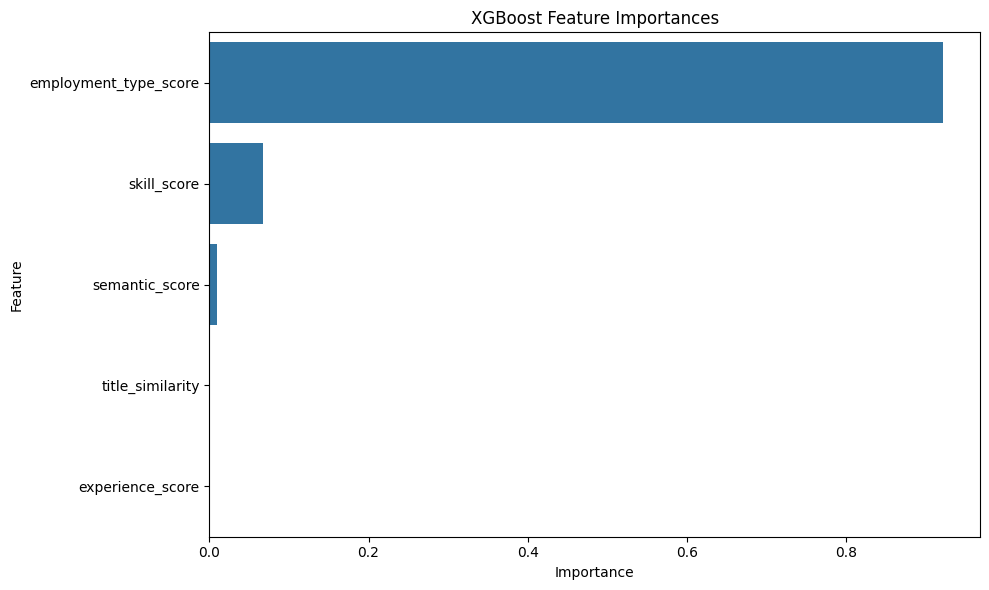

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Get feature names from X_train (or X, assuming they are the same)
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
candidate_location = "Delhi"

data["location_score"] = (
    data["location"]
    .str.lower()
    .eq(candidate_location.lower())
    .astype(float)
)


In [ ]:
# Use extracted candidate experience, defaulting to 0 if not found
candidate_experience_years = candidate_profile.get('experience', 0)

# The job's numerical experience is derived from experience_level
experience_level_map = {'Entry': 1, 'Mid': 2, 'Senior': 3}
data['numerical_experience'] = data['experience_level'].map(experience_level_map).fillna(0)

# Implement the requested experience_match logic: 1 if candidate experience >= job's numerical experience, else 0
data['experience_score'] = (candidate_experience_years >= data['numerical_experience']).astype(int)

print(f"Candidate experience (years): {candidate_experience_years}")
print(data[['experience_level', 'numerical_experience', 'experience_score']].head())

Candidate experience (years): 0
  experience_level  numerical_experience  experience_score
0              Mid                     2                 0
1           Senior                     3                 0
2            Entry                     1                 0
3              Mid                     2                 0
4           Senior                     3                 0


In [ ]:
candidate_employment_type = 'Full-time' # You can change this to 'Contract', 'Part-time', etc.

data['employment_type_score'] = (
    data['employment_type']
    .str.lower()
    .eq(candidate_employment_type.lower())
    .astype(float)
)

print(data[['employment_type', 'employment_type_score']].head())

  employment_type  employment_type_score
0       Full-time                    1.0
1       Full-time                    1.0
2       Full-time                    1.0
3       Full-time                    1.0
4        Contract                    0.0


In [ ]:
final_jobs[
    [
        'job_title',
        'skills_required',
         'semantic_score',
        'skill_score',
        'final_score',
         'dl_score',
        'location_score',
        'experience_score',
        'title_similarity'


    ]
].head(10)

,job_title,skills_required,semantic_score,skill_score,final_score,dl_score,location_score,experience_score,title_similarity
42,AI Product Manager,"NumPy, SQL, Python, Reinforcement Learning, La...",0.630046,0.75,0.597949,1.0,0.0,0,0.774330
1985,Data Analyst,"Reinforcement Learning, LangChain, MLflow, Hug...",0.605848,0.75,0.579725,1.0,0.0,0,0.676787
362,NLP Engineer,"Pandas, CUDA, AWS, TensorFlow, Python",0.565367,0.75,0.579647,1.0,0.0,0,0.817684
1239,AI Researcher,"Power BI, Pandas, Python, Keras, NumPy, Scikit...",0.557083,1.00,0.631259,1.0,0.0,0,0.862801
963,AI Product Manager,"NumPy, Pandas, SQL, R, Excel",0.583565,0.75,0.581681,1.0,0.0,0,0.774330
1883,NLP Engineer,"Reinforcement Learning, NumPy, Python, Pandas",0.503405,1.00,0.607960,1.0,0.0,0,0.817684
993,AI Researcher,"Python, Keras, AWS, CUDA, NumPy, R",0.585259,0.75,0.591121,1.0,0.0,0,0.862801
782,Data Scientist,"TensorFlow, Reinforcement Learning, Python, AW...",0.566853,0.75,0.567564,1.0,0.0,0,0.691654
751,Computer Vision Engineer,"NumPy, Azure, PyTorch, Python, Pandas, R",0.526556,1.00,0.611207,1.0,0.0,0,0.769123
1599,AI Product Manager,"Python, AWS, PyTorch, NumPy",0.572744,0.75,0.577893,1.0,0.0,0,0.774330


In [ ]:
pred = predictions

print(pred[:20])
print(pred.min())
print(pred.max())
print(pred.mean())

[[0.444795  ]
 [0.44813973]
 [0.4047646 ]
 [0.44378456]
 [0.4043069 ]
 [0.43920004]
 [0.38970348]
 [0.42515838]
 [0.40062135]
 [0.4444919 ]
 [0.40765315]
 [0.40314353]
 [0.4012671 ]
 [0.40467608]
 [0.40799704]
 [0.4347135 ]
 [0.4542707 ]
 [0.39793792]
 [0.43517035]
 [0.40146932]]
0.37828216
0.45443848
0.4226718


In [ ]:
import pandas as pd

df = X.copy()
df["label"] = y

corr = df.corr(numeric_only=True)["label"].sort_values(ascending=False)

print(corr)

label                    1.000000
employment_type_score    0.709399
skill_score              0.294649
semantic_score           0.292914
experience_score              NaN
location_score                NaN
Name: label, dtype: float64
